In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0,np.nan)

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_1278/1805888609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


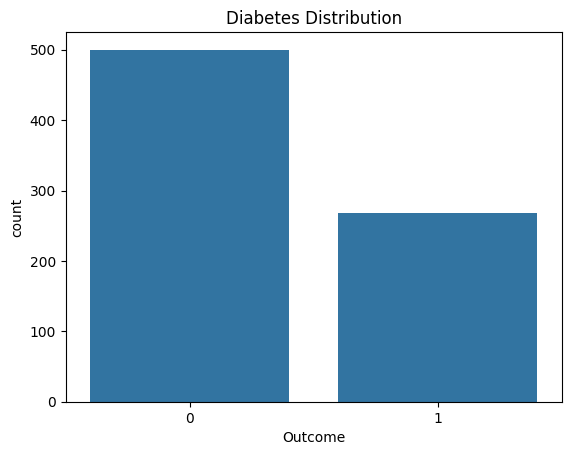

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Outcome',data=df)

plt.title('Diabetes Distribution')

plt.show()

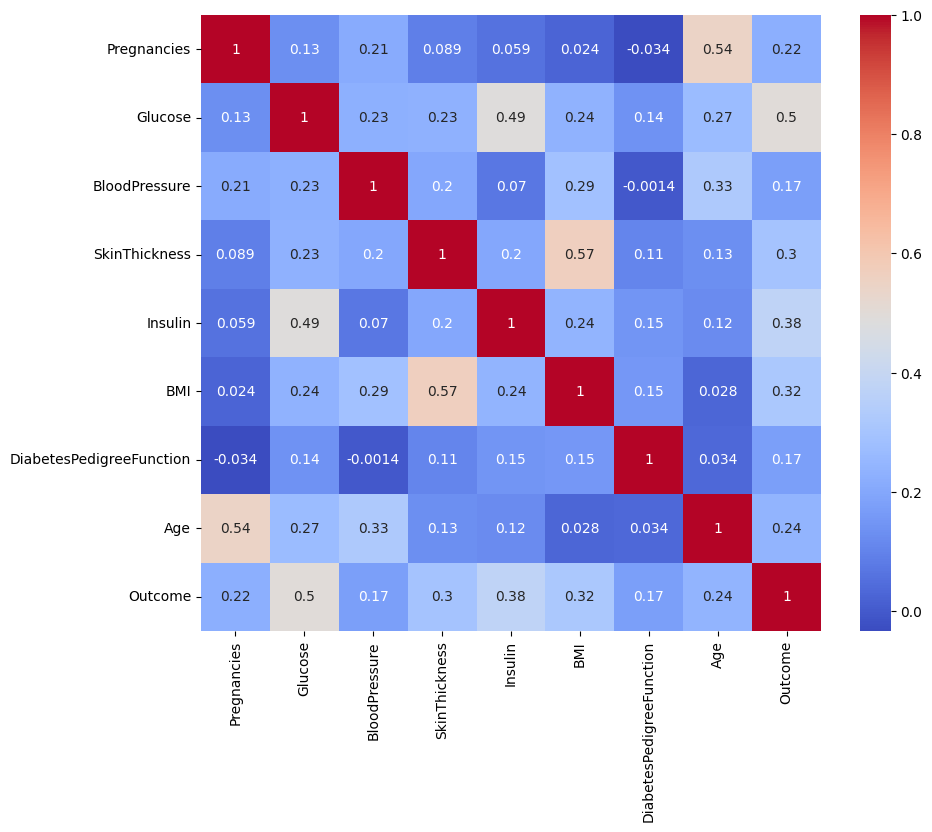

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome',axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.63994726,  0.86462486, -0.03218035,  0.66518138,  0.31160394,
         0.16948251,  0.46849198,  1.4259954 ],
       [-0.84488505, -1.20472661, -0.52812374, -0.01011181, -0.44084303,
        -0.84854874, -0.36506078, -0.19067191],
       [ 1.23388019,  2.01426457, -0.69343821,  0.32753478,  0.31160394,
        -1.32847775,  0.60439732, -0.10558415],
       [-0.84488505, -1.07333922, -0.52812374, -0.685405  , -0.53630272,
        -0.63039919, -0.92076261, -1.04154944],
       [-1.14185152,  0.50330953, -2.67721176,  0.66518138,  0.29475812,
         1.55109634,  5.4849091 , -0.0204964 ]])

In [9]:
from scipy.stats import ttest_ind

diabetic = df[df['Outcome']==1]['Glucose']
non_diabetic = df[df['Outcome']==0]['Glucose']

t_stat,p_val = ttest_ind(diabetic,
                         non_diabetic)

print("T-statistic:",t_stat)
print("P-value:",p_val)

T-statistic: 15.808983160790056
P-value: 6.22693313370198e-49


In [10]:
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[20,30,40,50,60,100],
                        labels=['20-30',
                                '30-40',
                                '40-50',
                                '50-60',
                                '60+'])

from scipy.stats import chi2_contingency

table = pd.crosstab(df['AgeGroup'],
                    df['Outcome'])

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-square:",chi2)
print("P-value:",p)

Chi-square: 81.6612857019655
P-value: 7.74411254791731e-17


In [11]:
df['BMI_Group'] = pd.cut(df['BMI'],
                         bins=[0,18.5,25,30,100],
                         labels=['Underweight',
                                 'Normal',
                                 'Overweight',
                                 'Obese'])

In [12]:
from scipy.stats import f_oneway

groups = [group['Glucose'].values
          for name,group in df.groupby('BMI_Group')]

f_stat,p_val = f_oneway(*groups)

print("F-statistic:",f_stat)

print("P-value:",p_val)

F-statistic: 13.500878158256349
P-value: 1.3657943712769507e-08


/tmp/ipykernel_1278/3218628869.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name,group in df.groupby('BMI_Group')]


In [13]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(f_classif,k=5)

X_new = selector.fit_transform(
    X,
    df['Outcome']
)

print(X.columns[selector.get_support()])

Index(['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age'], dtype='object')


In [14]:
text_df = pd.read_csv(
    '/content/drive/MyDrive/Symptom2Disease.csv'
)

text_df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [15]:
text_df.info()

text_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1200 non-null   int64 
 1   label       1200 non-null   object
 2   text        1200 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.3+ KB


,0
Unnamed: 0,0
label,0
text,0


In [16]:
text_df.dropna(inplace=True)

In [17]:
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [18]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [w for w in words
             if w not in stop_words]

    return " ".join(words)

text_df['clean_text'] = text_df['text'].apply(clean_text)

In [19]:
from collections import Counter

all_words = " ".join(
    text_df['clean_text']
)

Counter(
    all_words.split()
).most_common(20)

[('also', 418),
 ('skin', 384),
 ('lot', 353),
 ('really', 331),
 ('pain', 307),
 ('fever', 243),
 ('feel', 218),
 ('feeling', 217),
 ('experiencing', 208),
 ('high', 205),
 ('neck', 179),
 ('cough', 148),
 ('chest', 147),
 ('get', 147),
 ('quite', 139),
 ('headache', 134),
 ('throat', 131),
 ('rash', 130),
 ('hurts', 129),
 ('red', 114)]

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000
)

X_text = vectorizer.fit_transform(
    text_df['clean_text']
)

X_text.shape

(1200, 1444)

In [21]:
import os
import cv2

yes_path = '/content/drive/MyDrive/brain_tumor_dataset/yes'

sample_img = os.listdir(yes_path)[0]

img = cv2.imread(
    os.path.join(
        yes_path,
        sample_img
    )
)

img.shape

(246, 205, 3)

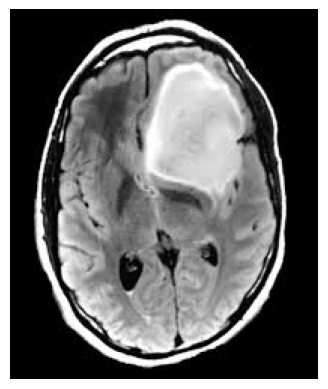

In [22]:
import matplotlib.pyplot as plt

plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis('off')

plt.show()

In [23]:
img = cv2.resize(
    img,
    (224,224)
)

img = img/255.0

img.shape

(224, 224, 3)

In [24]:
denoised = cv2.GaussianBlur(
    img,
    (5,5),
    0
)

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [26]:
yes_count = len(
    os.listdir(
        '/content/drive/MyDrive/brain_tumor_dataset/yes'
    )
)

no_count = len(
    os.listdir(
        '/content/drive/MyDrive/brain_tumor_dataset/no'
    )
)

print("Tumor:",yes_count)

print("No Tumor:",no_count)

Tumor: 155
No Tumor: 98


In [27]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00


In [28]:
import wfdb

record = wfdb.rdrecord(
    '/content/drive/MyDrive/100'
)

signal = record.p_signal

signal.shape

(650000, 2)

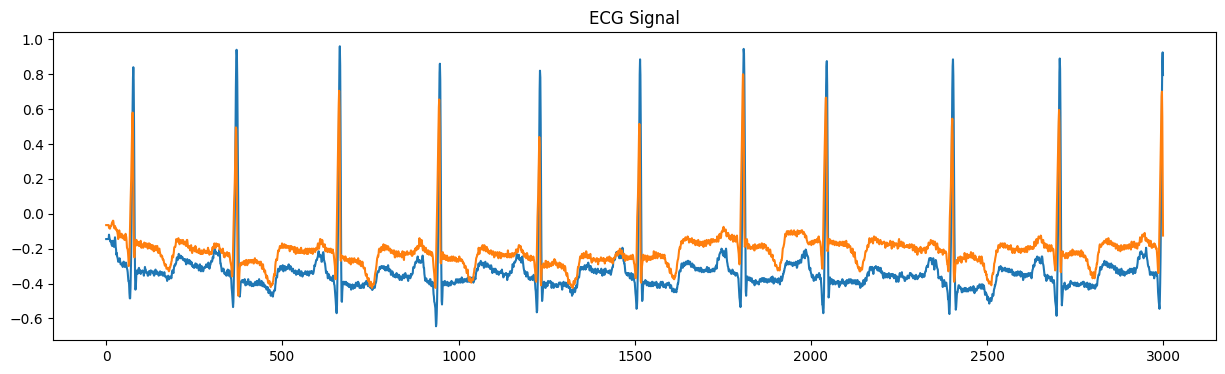

In [29]:
plt.figure(figsize=(15,4))

plt.plot(signal[:3000])

plt.title('ECG Signal')

plt.show()

In [30]:
from scipy.signal import butter,filtfilt

def lowpass(data,
            cutoff=40,
            fs=360,
            order=4):

    nyq = 0.5*fs

    normal = cutoff/nyq

    b,a = butter(
        order,
        normal,
        btype='low'
    )

    return filtfilt(
        b,
        a,
        data
    )

filtered = lowpass(signal[:,0])

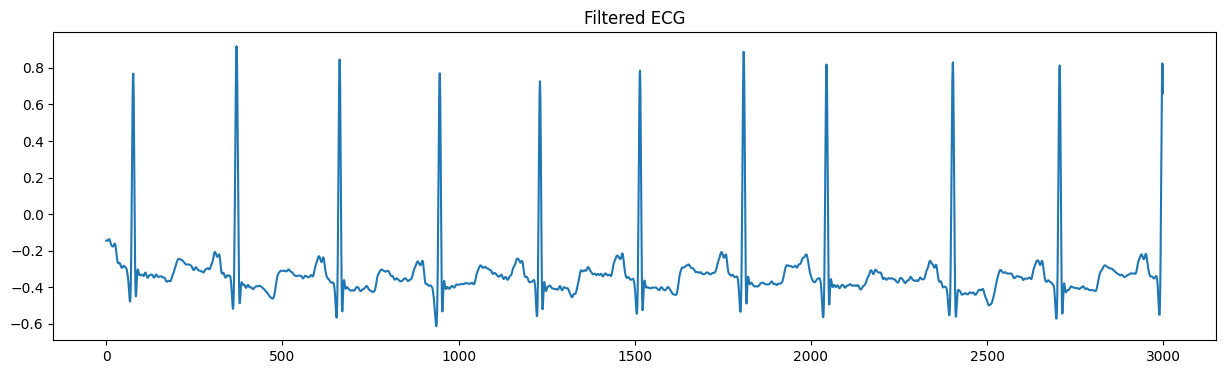

In [31]:
plt.figure(figsize=(15,4))

plt.plot(filtered[:3000])

plt.title('Filtered ECG')

plt.show()

In [32]:
window_size = 360

windows = []

for i in range(
    0,
    len(filtered)-window_size,
    window_size
):

    windows.append(
        filtered[i:i+window_size]
    )

windows = np.array(windows)

windows.shape

(1805, 360)

In [33]:
features = pd.DataFrame({

    'Mean':
    np.mean(windows,
            axis=1),

    'STD':
    np.std(windows,
           axis=1),

    'Energy':
    np.sum(windows**2,
           axis=1)
})

features.head()

,Mean,STD,Energy
0,-0.279415,0.139383,35.100009
1,-0.319942,0.219553,54.203785
2,-0.344406,0.144441,50.212342
3,-0.334563,0.134268,46.785805
4,-0.320564,0.146678,44.739170


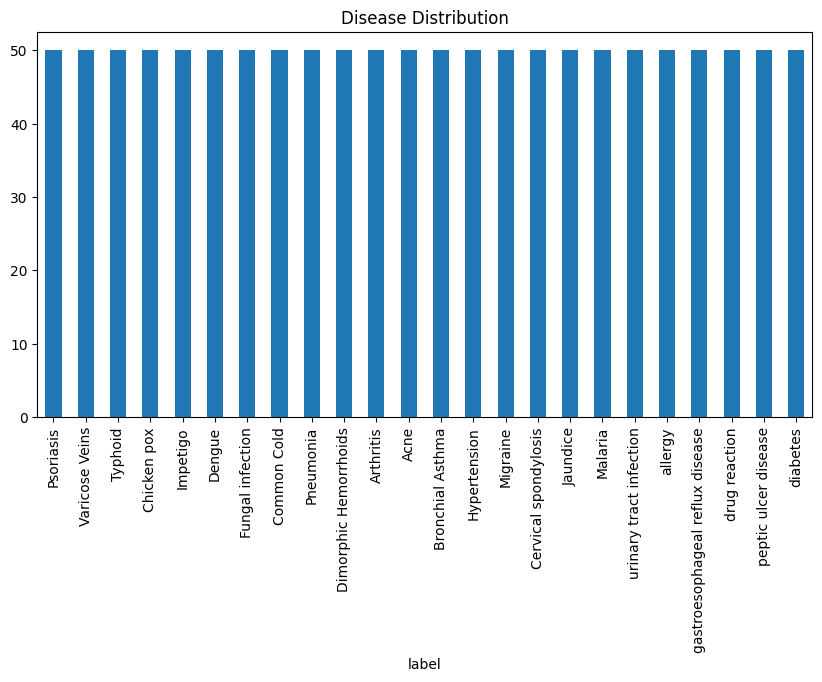

In [34]:
import matplotlib.pyplot as plt

text_df['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Disease Distribution")
plt.show()

In [35]:
!pip install wordcloud -q

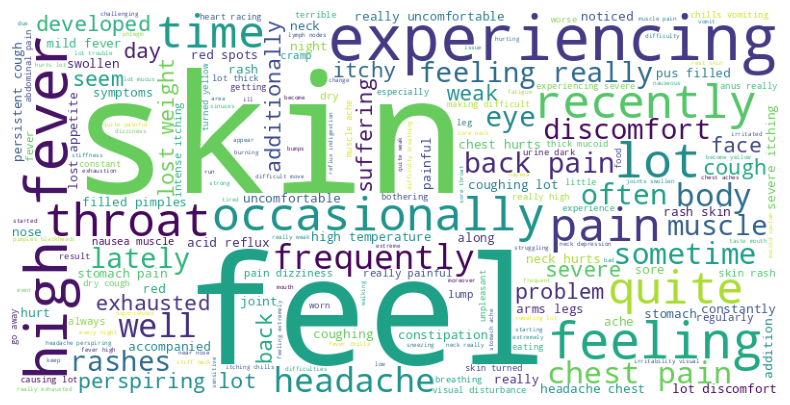

In [36]:
from wordcloud import WordCloud

text = " ".join(text_df['clean_text'])

wc = WordCloud(width=800,
               height=400,
               background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

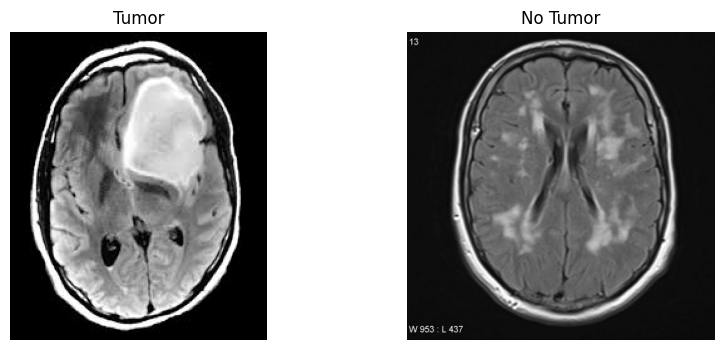

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

yes_path = "/content/drive/MyDrive/brain_tumor_dataset/yes"
no_path = "/content/drive/MyDrive/brain_tumor_dataset/no"

yes_img = cv2.imread(os.path.join(yes_path, os.listdir(yes_path)[0]))
no_img = cv2.imread(os.path.join(no_path, os.listdir(no_path)[0]))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(yes_img, cv2.COLOR_BGR2RGB))
plt.title("Tumor")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(no_img, cv2.COLOR_BGR2RGB))
plt.title("No Tumor")
plt.axis("off")

plt.show()

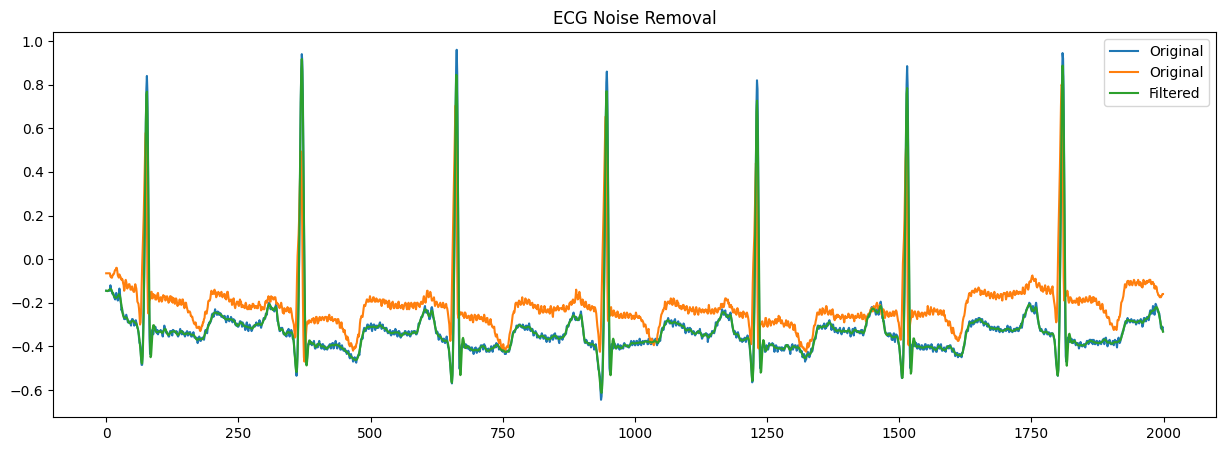

In [38]:
plt.figure(figsize=(15,5))

plt.plot(signal[:2000], label='Original')

plt.plot(filtered[:2000], label='Filtered')

plt.legend()

plt.title("ECG Noise Removal")

plt.show()

In [39]:
df.to_csv("processed_diabetes.csv", index=False)

In [40]:
text_df.to_csv("processed_symptom2disease.csv", index=False)